In [ ]:
!pip -q install transformers sentencepiece evaluate rouge-score beautifulsoup4 requests pandas tqdm scipy

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.9 MB/s eta 0:00:00


In [5]:
import os
import pandas as pd

BASE_DIR = "drive/MyDrive/comparison_dataset"

def load_group(group_name):
    folder = os.path.join(BASE_DIR, group_name)

    records = []

    for file in sorted(os.listdir(folder)):
        if (
            file.startswith("paper_")
            and file.endswith(".txt")
            and "_abstract" not in file
        ):

            idx = file.replace("paper_", "").replace(".txt", "")

            text_path = os.path.join(folder, file)
            abs_path = os.path.join(
                folder,
                f"paper_{idx}_abstract.txt"
            )

            if not os.path.exists(abs_path):
                continue

            with open(text_path, encoding="utf-8") as f:
                text = f.read()

            with open(abs_path, encoding="utf-8") as f:
                abstract = f.read()

            records.append({
                "group": group_name,
                "id": idx,
                "text": text,
                "reference": abstract
            })

    return records


old_records = load_group("old_2020")
new_records = load_group("new_2025")

records = old_records + new_records

print("OLD:", len(old_records))
print("NEW:", len(new_records))

OLD: 10
NEW: 10


In [6]:
from transformers import AutoTokenizer
from transformers import AutoModelForSeq2SeqLM
import torch

MODEL_NAME = "cointegrated/rut5-base-absum"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/753 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/315 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/828k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/977M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


T5ForConditionalGeneration(
  (shared): Embedding(30000, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(30000, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

In [7]:
def summarize(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=600
    ).to(device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_length=200,
            num_beams=5,
            no_repeat_ngram_size=3
        )

    return tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

In [8]:
import evaluate
from tqdm.auto import tqdm

rouge = evaluate.load("rouge")

results = []

for row in tqdm(records):

    prediction = summarize(row["text"])

    scores = rouge.compute(
        predictions=[prediction],
        references=[row["reference"]]
    )

    results.append({
        "group": row["group"],
        "id": row["id"],
        "rouge1": scores["rouge1"],
        "rouge2": scores["rouge2"],
        "rougeL": scores["rougeL"],
        "prediction": prediction
    })

results_df = pd.DataFrame(results)

  0%|          | 0/20 [00:00<?, ?it/s]

In [9]:
results_df.groupby("group")[
    ["rouge1","rouge2","rougeL"]
].mean()

,rouge1,rouge2,rougeL
group,,,
new_2025,0.146667,0.0,0.146667
old_2020,0.033333,0.0,0.033333


In [10]:
from scipy.stats import mannwhitneyu

for metric in ["rouge1","rouge2","rougeL"]:

    old_scores = results_df[
        results_df.group=="old_2020"
    ][metric]

    new_scores = results_df[
        results_df.group=="new_2025"
    ][metric]

    stat, p = mannwhitneyu(
        new_scores,
        old_scores,
        alternative="two-sided"
    )

    print(metric)
    print("old mean =", old_scores.mean())
    print("new mean =", new_scores.mean())
    print("p-value =", p)
    print("-"*50)

rouge1
old mean = 0.03333333333333334
new mean = 0.14666666666666667
p-value = 0.5036312588983317
--------------------------------------------------
rouge2
old mean = 0.0
new mean = 0.0
p-value = 1.0
--------------------------------------------------
rougeL
old mean = 0.03333333333333334
new mean = 0.14666666666666667
p-value = 0.5036312588983317
--------------------------------------------------


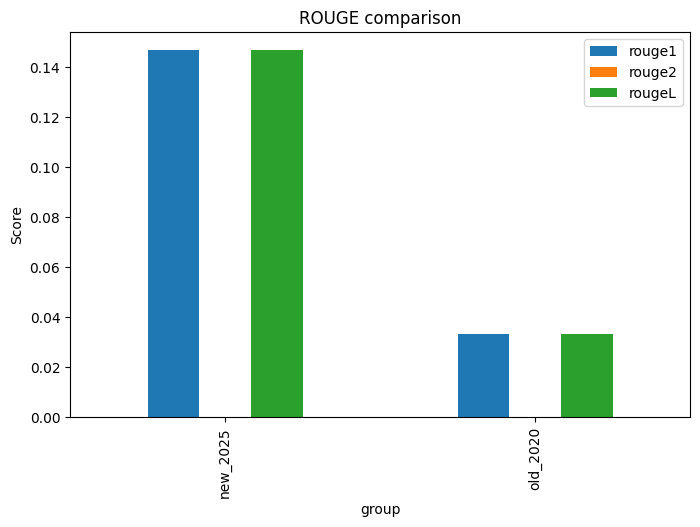

In [11]:
import matplotlib.pyplot as plt

metrics = ["rouge1","rouge2","rougeL"]

means = results_df.groupby("group")[metrics].mean()

means.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Score")
plt.title("ROUGE comparison")
plt.show()

In [12]:
!pip -q install sacrebleu nltk

import evaluate
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

nltk.download("wordnet")
nltk.download("omw-1.4")

meteor = evaluate.load("meteor")
chrf = evaluate.load("chrf")
smooth = SmoothingFunction().method1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.3 MB/s eta 0:00:00


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [21]:
# =========================
# Расчёт ROUGE + METEOR + BLEU + chrF
# =========================

results = []

for row in tqdm(records):
    prediction = summarize(row["text"])
    reference = row["reference"]

    rouge_scores = rouge.compute(
        predictions=[prediction],
        references=[reference]
    )

    meteor_score = meteor.compute(
        predictions=[prediction],
        references=[reference]
    )["meteor"]

    chrf_score = chrf.compute(
        predictions=[prediction],
        references=[reference]
    )["score"]

    bleu_score = sentence_bleu(
        [reference.split()],
        prediction.split(),
        smoothing_function=smooth
    )

    results.append({
    "group": row["group"],
    "id": row["id"],

    "rouge1": rouge_scores["rouge1"] * 100,
    "rouge2": rouge_scores["rouge2"] * 100,
    "rougeL": rouge_scores["rougeL"] * 100,

    "meteor": meteor_score * 100,
    "bleu": bleu_score * 100,

    # chrF уже в процентах
    "chrf": chrf_score,

    "prediction": prediction,
    "reference": reference
    })



  0%|          | 0/20 [00:00<?, ?it/s]

In [22]:


results_df = pd.DataFrame(results)

display(results_df)

,group,id,rouge1,rouge2,rougeL,meteor,bleu,chrf,prediction,reference
0,old_2020,01,0.000000,0.0,0.000000,1.736111,0.324538,17.491581,Генетические и эволюционные относятся к классу...,Данная работа посвящена решению квадратичной з...
1,old_2020,02,0.000000,0.0,0.000000,1.165501,0.016684,5.536612,Создать отчёт-таблицу в виде наглядного отчёта...,В статье рассмотрен инструмент «Сводные таблиц...
2,old_2020,03,0.000000,0.0,0.000000,1.851852,0.565640,13.569489,Выберите оптимальную технологию разработки веб...,В статье рассказывается о возможности PWA (pro...
3,old_2020,04,0.000000,0.0,0.000000,0.000000,0.000000,11.367148,Популяционные алгоритмы относятся к классу эвр...,В данной статье рассматривается популяционный ...
4,old_2020,05,0.000000,0.0,0.000000,12.975871,1.032900,22.761395,Введём постановку трёхмерной упаковки разногаб...,В статье рассматривается одна из задач комбина...
5,old_2020,06,0.000000,0.0,0.000000,0.000000,0.000000,5.833823,Внедрение систем голосового обслуживания,В статье рассматривается задача распознавания ...
6,old_2020,07,0.000000,0.0,0.000000,2.504174,0.000000,6.647535,На кафедре информационных технологий КубГУ раз...,В статье предлагается модель машинного обучени...
7,old_2020,08,0.000000,0.0,0.000000,4.889976,0.000000,15.227907,Работа алгоритма состоит из следующих этапов. ...,В статье предлагается алгоритм распознавания д...
8,old_2020,09,0.000000,0.0,0.000000,9.090909,0.567083,37.748979,Технология искусственного искусственного мышле...,В рамках данной работы разработана распределён...
9,old_2020,10,33.333333,0.0,33.333333,2.384738,0.003252,7.319954,Метод глубокого обучения по изучению языка про...,В статье рассматривается одна из основных зада...


In [23]:
metrics = [
    "rouge1",
    "rouge2",
    "rougeL",
    "meteor",
    "bleu",
    "chrf"
]

summary_table = results_df.groupby("group")[metrics].agg(
    ["mean", "std", "median", "count"]
)

display(summary_table)

rouge1                         rouge2                    \
               mean        std median count   mean  std median count   
group                                                                  
new_2025  14.666667  31.079349    0.0    10    0.0  0.0    0.0    10   
old_2020   3.333333  10.540926    0.0    10    0.0  0.0    0.0    10   

             rougeL             ...    meteor            bleu            \
               mean        std  ...    median count      mean       std   
group                           ...                                       
new_2025  14.666667  31.079349  ...  6.539562    10  0.598639  0.583977   
old_2020   3.333333  10.540926  ...  2.118295    10  0.251010  0.362701   

                               chrf                              
            median count       mean        std     median count  
group                                                            
new_2025  0.583970    10  23.939726  11.399821  25.213658    10  
old_2020  0.009968    10  14.350442   9.985329  12.468319    10  

[2 rows x 24 columns]

In [24]:
from scipy.stats import mannwhitneyu

comparison_rows = []

for metric in metrics:
    old_scores = results_df[results_df.group == "old_2020"][metric].dropna()
    new_scores = results_df[results_df.group == "new_2025"][metric].dropna()

    stat, p = mannwhitneyu(
        new_scores,
        old_scores,
        alternative="two-sided"
    )

    comparison_rows.append({
        "metric": metric,
        "old_mean": old_scores.mean(),
        "new_mean": new_scores.mean(),
        "difference_new_minus_old": new_scores.mean() - old_scores.mean(),
        "p_value": p
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,metric,old_mean,new_mean,difference_new_minus_old,p_value
0,rouge1,3.333333,14.666667,11.333333,0.503631
1,rouge2,0.000000,0.000000,0.000000,1.000000
2,rougeL,3.333333,14.666667,11.333333,0.503631
3,meteor,3.659913,8.606815,4.946902,0.021085
4,bleu,0.251010,0.598639,0.347630,0.062026
5,chrf,14.350442,23.939726,9.589283,0.053903


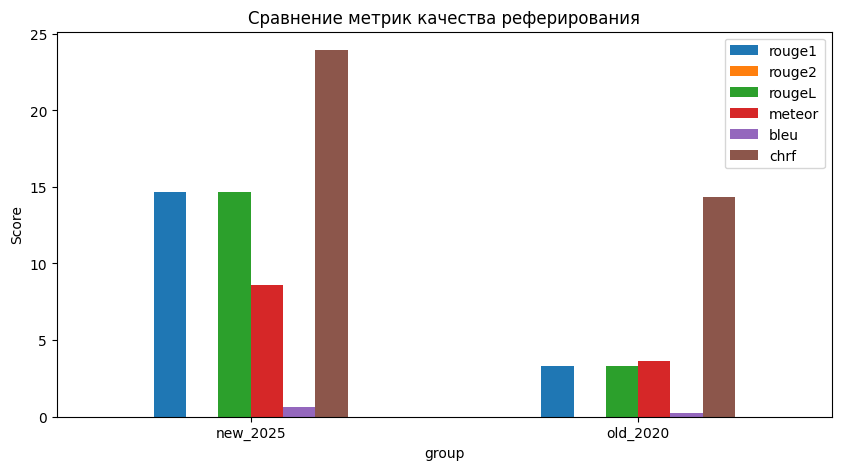

In [25]:
import matplotlib.pyplot as plt

means = results_df.groupby("group")[metrics].mean()

means.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Score")
plt.title("Сравнение метрик качества реферирования")
plt.xticks(rotation=0)
plt.show()